In [7]:
############################################################
# Minimal Power System Simulation (Julia Version)
# Based on "Extended State Estimation - Minimal Model"
# Original Author (MATLAB): Patrick Panciatici
############################################################
using DifferentialEquations
using Plots
using CSV
using DataFrames

############################################################
# Parameters
############################################################

# Nominal frequency
f0 = 50
ω0 = 2π * f0  # rad/s

# Line data
KL_nom = 3064.0     # MW/rad (two lines)
KL_one = 1532.0     # MW/rad (after one line trips)
KL = KL_nom

# Generator parameters
P0 = [600.0, 400.0]      # MW, setpoints
Pmax = [1000.0, 600.0]
Pmin = [0.0, 0.0]
Pr = [100.0, 50.0]
J = [0.4, 0.2]
D = [0.04, 0.02]
α = [100.0, 100.0]
β = [2000.0, 2000.0]
Ks = 0.05

# Load data
PL0 = [400.0, 600.0]

# Events
t_end = 60.0
t_line_trip = 15.0
t_load_step = 15.0
eventType = "loadRamp1" ;  # "loadStep2", "loadRamp1", "lineTrip" ; etc.


In [8]:
############################################################
# Initial steady-state computation
############################################################

θ1₀ = 0.0;
θ2₀ = asin((PL0[1] - P0[1]) / KL);
ω₀ = [ω0, ω0];
Tm₀ = [P0[1]/ω0, P0[2]/ω0];

x0 = [θ1₀, θ2₀, ω₀[1], ω₀[2], Tm₀[1], Tm₀[2], 0.0, PL0[1], PL0[2]];

In [9]:
############################################################
# Pack parameters
############################################################

params = (
    J = J, D = D, α = α, β = β,
    P0 = P0, Pr = Pr, Pmax = Pmax, Pmin = Pmin,
    KL_nom = KL_nom, KL_one = KL_one, Ks = Ks,
    eventType = eventType,
    t_line_trip = t_line_trip, t_load_step = t_load_step,
    ω0 = ω0
)

(J = [0.4, 0.2], D = [0.04, 0.02], α = [100.0, 100.0], β = [2000.0, 2000.0], P0 = [600.0, 400.0], Pr = [100.0, 50.0], Pmax = [1000.0, 600.0], Pmin = [0.0, 0.0], KL_nom = 3064.0, KL_one = 1532.0, Ks = 0.05, eventType = "loadRamp1", t_line_trip = 15.0, t_load_step = 15.0, ω0 = 314.1592653589793)

In [10]:
############################################################
# ODE System
############################################################

function powerSystemODE!(dx, x, p, t)
    # Unpack state vector
    θ1, θ2, ω1, ω2, Tm1, Tm2, N, PL1, PL2 = x

    # Unpack parameters
    J, D, α, β = p.J, p.D, p.α, p.β
    P0, Pr, Pmax, Pmin = p.P0, p.Pr, p.Pmax, p.Pmin
    Ks, ω0 = p.Ks, p.ω0
    KL_nom, KL_one = p.KL_nom, p.KL_one
    eventType, t_line_trip, t_load_step = p.eventType, p.t_line_trip, p.t_load_step

    # Initialize dynamic quantities
    ΔPL = 0.0
    KL = KL_nom

    # === Events ===
    if eventType == "loadRamp1"
        ΔPL = 100 / 60
    elseif eventType == "loadRamp2"
        ΔPL = 200 / 60
    elseif eventType == "loadStep1" && t ≥ t_load_step
        PL1 = 500.0
    elseif eventType == "loadStep2" && t ≥ t_load_step
        PL1 = 600.0
    elseif eventType == "lineTrip" && t ≥ t_line_trip
        KL = KL_one
    end

    # Grid equations
    F12 = KL * sin(θ1 - θ2)
    F21 = -F12
    PG1 = PL1 + F12
    PG2 = PL2 + F21

    # Frequency center
    ωr = (J[1]*ω1 + J[2]*ω2) / sum(J)

    # Secondary frequency control
    Ndot = abs(N) ≤ 1 ? -Ks*(ωr - ω0) : 0.0

    PLdot1 = ΔPL
    PLdot2 = 0.0

    # Generator 1
    Pc1 = clamp(P0[1] + N*Pr[1], Pmin[1], Pmax[1])
    Pm1 = Tm1 * ω1
    Tmdot1 = (Pm1 ≥ Pmin[1] && Pm1 ≤ Pmax[1]) ? -α[1]*(Pm1 - Pc1) - β[1]*(ω1 - ω0) : 0.0
    ωdot1 = (Tm1 - PG1/ω1 - D[1]*(ω1 - ω0)) / J[1]
    θdot1 = ω1 - ω0

    # Generator 2
    Pc2 = clamp(P0[2] + N*Pr[2], Pmin[2], Pmax[2])
    Pm2 = Tm2 * ω2
    Tmdot2 = (Pm2 ≥ Pmin[2] && Pm2 ≤ Pmax[2]) ? -α[2]*(Pm2 - Pc2) - β[2]*(ω2 - ω0) : 0.0
    ωdot2 = (Tm2 - PG2/ω2 - D[2]*(ω2 - ω0)) / J[2]
    θdot2 = ω2 - ω0

    dx .= [θdot1, θdot2, ωdot1, ωdot2, Tmdot1, Tmdot2, Ndot, PLdot1, PLdot2]
end


powerSystemODE! (generic function with 1 method)

In [11]:
############################################################
# Simulation
############################################################

tspan = (0.0, t_end)
prob = ODEProblem(powerSystemODE!, x0, tspan, params)
sol = solve(prob, Rodas5(), reltol=1e-4, abstol=1e-6)

############################################################
# Results
############################################################

θ = hcat(sol[1,:], sol[2,:]);
ω = hcat(sol[3,:], sol[4,:]);
Tm = hcat(sol[5,:], sol[6,:]);
N = sol[7,:];
PL = hcat(sol[8,:], sol[9,:]);
t = sol.t;

# Saving results in a csv file
df_results = DataFrame(
    time = t,
    theta1 = θ[:,1],
    theta2 = θ[:,2],
    omega1 = ω[:,1],
    omega2 = ω[:,2],
    Tm1 = Tm[:,1],
    Tm2 = Tm[:,2],
    N = N,
    PL1 = PL[:,1],
    PL2 = PL[:,2]
)

# Add constant simulation parameters as new columns (broadcast to all rows)
df_results[!, :PL0_1] = fill(PL0[1], length(t))
df_results[!, :PL0_2] = fill(PL0[2], length(t))
df_results[!, :P0_1]  = fill(P0[1], length(t))
df_results[!, :P0_2]  = fill(P0[2], length(t))
df_results[!, :Pmax_1] = fill(Pmax[1], length(t))
df_results[!, :Pmax_2] = fill(Pmax[2], length(t))
df_results[!, :KL_nom] = fill(KL_nom, length(t))
df_results[!, :KL_one] = fill(KL_one, length(t))
df_results[!, :t_line_trip] = fill(t_line_trip, length(t))

CSV.write("Res_Sim_$(eventType).csv", df_results)
println("Simulation data saved to Res_Sim_$(eventType).csv")


Simulation data saved to Res_Sim_loadRamp1.csv


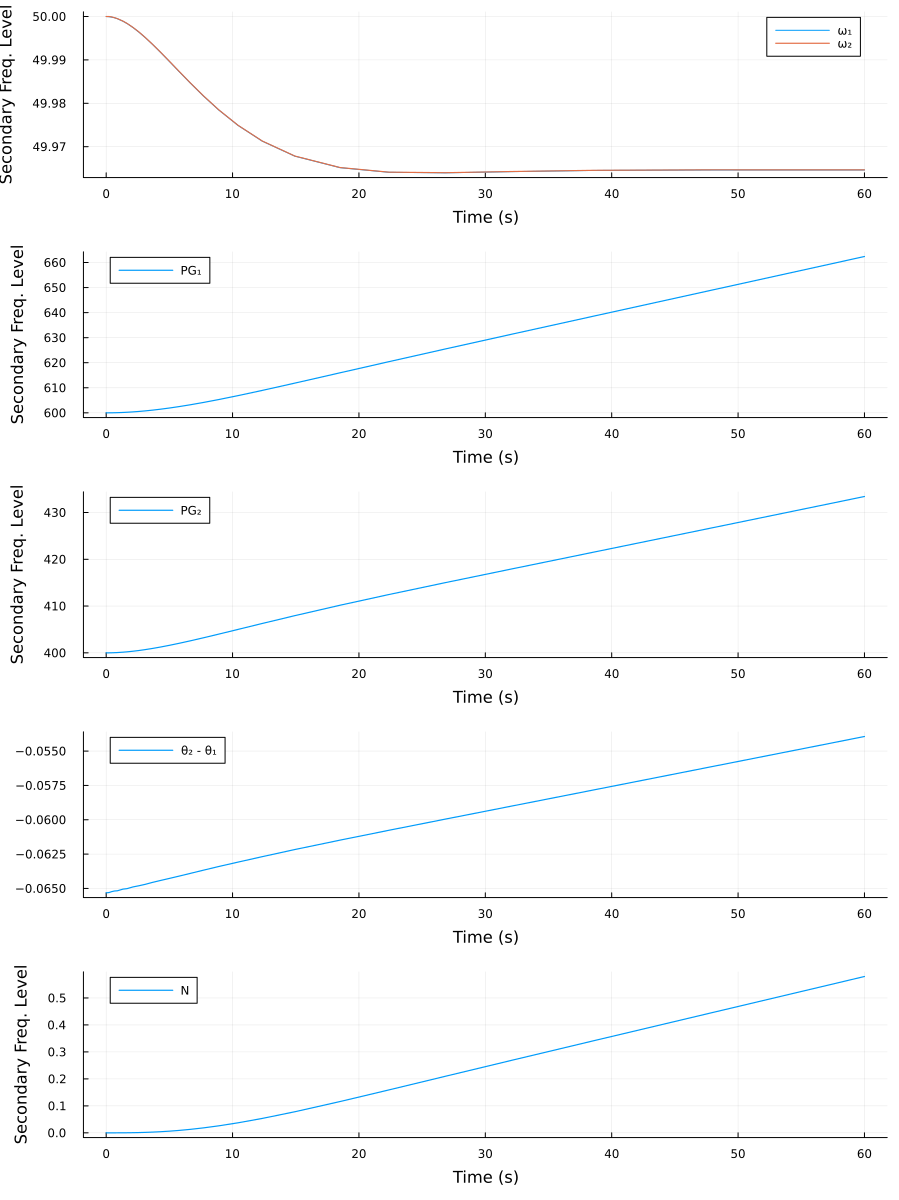

In [12]:
############################################################
# Plotting
############################################################

fig = plot(layout=(5,1), size=(900, 1200), grid=true)
plot!(fig,t, ω[:,1]/(2π), label="ω₁", lw=1)
plot!(fig,t, ω[:,2]/(2π), label="ω₂", lw=1.2, subplot=1, grid=true)
ylabel!("Frequency (Hz)")

plot!(fig,t, Tm[:,1].*ω[:,1], label="PG₁", lw=1.2, subplot=2, grid=true)
ylabel!("Power G1 (MW)"); 

plot!(fig,t, Tm[:,2].*ω[:,2], label="PG₂", lw=1.2, subplot=3, grid=true)
ylabel!("Power G2 (MW)");

plot!(fig, t, θ[:,2] - θ[:,1], label="θ₂ - θ₁", lw=1.2, subplot=4, grid=true)
ylabel!("Angle Diff (rad)"); 

plot!(fig, t, N, label="N", lw=1.2, subplot=5, grid=true)
ylabel!("Secondary Freq. Level")
xlabel!("Time (s)")

display(fig)